In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
import lightgbm as lgb
import xgboost as xgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Loading processed features...")
features_df = pd.read_csv('../preprocessing/processed_features.csv')
print(f"Loaded data shape: {features_df.shape}")

Loading processed features...
Loaded data shape: (75000, 32)
Loaded data shape: (75000, 32)


### Data quality check

In [38]:
def check_data_quality(df):
    """Comprehensive data quality assessment"""
    print("=== DATA QUALITY CHECK ===")
    
    # Missing values
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    print("\nMissing Values:")
    for col, count in missing_data.items():
        if count > 0:
            print(f"  {col}: {count} ({missing_percent[col]:.2f}%)")
    
    # Constant columns
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    print(f"\nConstant columns: {constant_cols}")
    
    # Data types
    print(f"\nData types:")
    print(df.dtypes.value_counts())
    
    return missing_data, constant_cols

missing_data, constant_cols = check_data_quality(features_df)

=== DATA QUALITY CHECK ===

Missing Values:
  value: 940 (1.25%)

Constant columns: []

Data types:
int64      15
object      8
float64     6
bool        3
Name: count, dtype: int64


### Handle missing values

In [39]:
def handle_missing_values(df):
    """Handle missing values in the dataset"""
    df_clean = df.copy()
    
    # Ensure binary indicator columns are numeric
    bool_columns = [
        'enhanced_has_technical_specs',
        'enhanced_has_ingredients',
        'enhanced_has_benefits',
        'enhanced_extracted_dimensions',
        'detailed_has_usage_instructions',
        'detailed_has_warranty_info'
    ]
    for col in bool_columns:
        if col in df_clean.columns:
            # Accept actual bools, NaN, and string labels
            df_clean[col] = (
                df_clean[col]
                .replace({'True': True, 'False': False, 'true': True, 'false': False})
                .fillna(False)
                .astype(bool)
                .astype(int)
            )
    
    # Handle missing 'value' (1.3% of data)
    value_missing_mask = df_clean['value'].isnull()
    value_median = df_clean['value'].median()
    df_clean['value_missing'] = value_missing_mask.astype(int)
    df_clean['value'] = df_clean['value'].fillna(value_median)
    
    print("Missing values handled:")
    print(f"  - value: filled {value_missing_mask.sum()} missing values with median {value_median:.2f}")
    print("  - Created missing indicator: value_missing")
    print(f"  - Converted boolean-like columns to integers: {bool_columns}")
    
    return df_clean

features_clean = handle_missing_values(features_df)
print(f"Data shape after handling missing values: {features_clean.shape}")

Missing values handled:
  - value: filled 940 missing values with median 16.00
  - Created missing indicator: value_missing
  - Converted boolean-like columns to integers: ['enhanced_has_technical_specs', 'enhanced_has_ingredients', 'enhanced_has_benefits', 'enhanced_extracted_dimensions', 'detailed_has_usage_instructions', 'detailed_has_warranty_info']
Data shape after handling missing values: (75000, 33)


### Analyze categorical features

In [40]:
def analyze_categorical_features(df):
    """Analyze categorical features for encoding strategy"""
    categorical_features = ['brand', 'category', 'unit']
    
    print("=== CATEGORICAL FEATURE ANALYSIS ===")
    
    for feature in categorical_features:
        unique_count = df[feature].nunique()
        value_counts = df[feature].value_counts()
        
        print(f"\n{feature}:")
        print(f"  Unique values: {unique_count}")
        print(f"  Top 5 values:")
        for val, count in value_counts.head().items():
            percentage = (count / len(df)) * 100
            print(f"    {val}: {count} ({percentage:.1f}%)")
        
        # Encoding recommendation
        if unique_count <= 10:
            print(f"  → Recommendation: One-Hot Encoding")
        else:
            print(f"  → Recommendation: Target Encoding / Frequency Encoding")
    
    return categorical_features

categorical_features = analyze_categorical_features(features_clean)


=== CATEGORICAL FEATURE ANALYSIS ===

brand:
  Unique values: 9690
  Top 5 values:
    food: 1020 (1.4%)
    the: 648 (0.9%)
    mccormick: 633 (0.8%)
    organic: 473 (0.6%)
    rani: 425 (0.6%)
  → Recommendation: Target Encoding / Frequency Encoding

category:
  Unique values: 7
  Top 5 values:
    other: 39656 (52.9%)
    beverage: 15586 (20.8%)
    condiment: 7054 (9.4%)
    snack: 6899 (9.2%)
    grain: 3974 (5.3%)
  → Recommendation: One-Hot Encoding

unit:
  Unique values: 62
  Top 5 values:
    ounce: 44026 (58.7%)
    count: 18258 (24.3%)
    fl oz: 11271 (15.0%)
    none: 940 (1.3%)
    pound: 240 (0.3%)
  → Recommendation: Target Encoding / Frequency Encoding


### Encode categorical features

In [41]:
class CategoricalEncoder:
    """Handle encoding of categorical features"""
    
    def __init__(self):
        self.encoders = {}
        self.frequency_maps = {}
        self.target_encoders = {}
        
    def fit_transform(self, df, target_col=None):
        """Fit and transform categorical features"""
        df_encoded = df.copy()
        
        for col in ['brand', 'category', 'unit']:
            if col == 'brand':  # High cardinality
                # Frequency encoding for brand
                freq_map = df_encoded[col].value_counts().to_dict()
                self.frequency_maps[col] = freq_map
                df_encoded[f'{col}_freq'] = df_encoded[col].map(freq_map)
                
                # Target encoding if target is provided
                if target_col is not None:
                    target_mean = df_encoded.groupby(col)[target_col].mean().to_dict()
                    self.target_encoders[col] = target_mean
                    df_encoded[f'{col}_target'] = df_encoded[col].map(target_mean)
                
            else:  # Low/medium cardinality - One-Hot Encoding
                encoder = OneHotEncoder(sparse_output=False, drop='first')
                encoded_array = encoder.fit_transform(df_encoded[[col]])
                encoded_df = pd.DataFrame(
                    encoded_array, 
                    columns=[f"{col}_{cat}" for cat in encoder.categories_[0][1:]]
                )
                df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
                self.encoders[col] = encoder
            
            # Drop original categorical column
            df_encoded = df_encoded.drop(col, axis=1)
        
        return df_encoded
    
    def transform(self, df):
        """Transform new data using fitted encoders"""
        df_encoded = df.copy()
        
        for col in ['brand', 'category', 'unit']:
            if col in df_encoded.columns:
                if col == 'brand':  # High cardinality
                    if col in self.frequency_maps:
                        df_encoded[f'{col}_freq'] = df_encoded[col].map(self.frequency_maps[col]).fillna(0)
                    if col in self.target_encoders:
                        df_encoded[f'{col}_target'] = df_encoded[col].map(self.target_encoders[col]).fillna(
                            df_encoded[target_col].mean() if hasattr(self, 'target_col') else 0
                        )
                else:  # One-Hot Encoding
                    if col in self.encoders:
                        encoded_array = self.encoders[col].transform(df_encoded[[col]])
                        encoded_df = pd.DataFrame(
                            encoded_array, 
                            columns=[f"{col}_{cat}" for cat in self.encoders[col].categories_[0][1:]]
                        )
                        df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
                
                # Drop original categorical column
                df_encoded = df_encoded.drop(col, axis=1)
        
        return df_encoded

def sanitize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize feature names to avoid characters LightGBM cannot handle"""
    sanitized = df.copy()
    new_columns = []
    used_names = set()
    for idx, col in enumerate(sanitized.columns):
        clean = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip('_')
        if not clean:
            clean = f"feature_{idx}"
        if clean[0].isdigit():
            clean = f"f_{clean}"
        base_name = clean
        suffix = 1
        while clean in used_names:
            suffix += 1
            clean = f"{base_name}_{suffix}"
        used_names.add(clean)
        new_columns.append(clean)
    sanitized.columns = new_columns
    return sanitized

# Encode categorical features
print("Encoding categorical features...")
encoder = CategoricalEncoder()
features_encoded = encoder.fit_transform(features_clean, target_col='price')
features_encoded = sanitize_column_names(features_encoded)

print(f"Data shape after encoding: {features_encoded.shape}")
print(f"New columns: {list(features_encoded.columns)}")

Encoding categorical features...
Data shape after encoding: (75000, 99)
New columns: ['item_name_length', 'word_count', 'value', 'normalized_quantity', 'is_premium', 'has_organic', 'has_premium', 'enhanced_bullet_point_count', 'enhanced_total_bullet_length', 'enhanced_avg_bullet_length', 'enhanced_has_technical_specs', 'enhanced_has_ingredients', 'enhanced_has_benefits', 'enhanced_premium_keywords_count', 'enhanced_quality_indicators', 'enhanced_extracted_weight', 'enhanced_extracted_dimensions', 'detailed_description_length', 'detailed_description_word_count', 'detailed_avg_word_length', 'detailed_sentence_count', 'detailed_technical_term_count', 'detailed_marketing_language_score', 'detailed_positive_word_count', 'detailed_confidence_indicators', 'detailed_has_usage_instructions', 'detailed_has_warranty_info', 'sample_id', 'price', 'value_missing', 'brand_freq', 'brand_target', 'category_condiment', 'category_grain', 'category_other', 'category_personal_care', 'category_snack', 'cate

### Analyze feature skewness

In [42]:
def analyze_skewness(df, target_col='price'):
    """Analyze skewness of numerical features"""
    numerical_features = df.select_dtypes(include=[np.number]).columns
    numerical_features = [f for f in numerical_features if f not in ['sample_id', target_col]]
    
    print("=== FEATURE SKEWNESS ANALYSIS ===")
    
    skewness_data = []
    for feature in numerical_features:
        skew = stats.skew(df[feature].dropna())
        skewness_data.append((feature, skew, np.abs(skew)))
    
    # Sort by absolute skewness
    skewness_data.sort(key=lambda x: x[2], reverse=True)
    
    print("\nTop 10 most skewed features:")
    for feature, skew, abs_skew in skewness_data[:10]:
        print(f"  {feature}: {skew:.3f}")
    
    # Target skewness
    target_skew = stats.skew(df[target_col])
    print(f"\nTarget ({target_col}) skewness: {target_skew:.3f}")
    if abs(target_skew) > 1:
        print("  → Recommendation: Consider log transformation for target")
    else:
        print("  → Target is reasonably symmetric")
    
    return skewness_data, target_skew

skewness_data, target_skew = analyze_skewness(features_encoded)

=== FEATURE SKEWNESS ANALYSIS ===

Top 10 most skewed features:
  unit_1_pk_color_s_black_product_type_permanent_pack_quantity_1_tip_type_chisel_dimensions_overall_product_weight_0_06_lbs: 273.856
  unit_20_oz: 273.856
  unit_24: 273.856
  unit_8: 273.856
  unit_bottles: 273.856
  unit_box_12: 273.856
  unit_bucket: 273.856
  unit_case: 273.856
  unit_comes_as_a_single_0_1_oz_stick_for_on_the_go_use: 273.856
  unit_fl_oz_3: 273.856

Target (price) skewness: 13.601
  → Recommendation: Consider log transformation for target

Top 10 most skewed features:
  unit_1_pk_color_s_black_product_type_permanent_pack_quantity_1_tip_type_chisel_dimensions_overall_product_weight_0_06_lbs: 273.856
  unit_20_oz: 273.856
  unit_24: 273.856
  unit_8: 273.856
  unit_bottles: 273.856
  unit_box_12: 273.856
  unit_bucket: 273.856
  unit_case: 273.856
  unit_comes_as_a_single_0_1_oz_stick_for_on_the_go_use: 273.856
  unit_fl_oz_3: 273.856

Target (price) skewness: 13.601
  → Recommendation: Consider log tran

### Handle skewed features and scaling

In [43]:
def handle_skewed_features(df, target_col='price', skew_threshold=1.0):
    """Handle skewed features and apply scaling"""
    df_transformed = df.copy()
    
    numerical_features = df.select_dtypes(include=[np.number]).columns
    numerical_features = [f for f in numerical_features if f not in ['sample_id', target_col]]
    
    # Log transform highly skewed features
    highly_skewed = []
    for feature in numerical_features:
        skew = stats.skew(df[feature].dropna())
        if np.abs(skew) > skew_threshold:
            # Add small constant to handle zeros
            min_val = df[feature].min()
            if min_val <= 0:
                constant = np.abs(min_val) + 1
            else:
                constant = 0
            
            df_transformed[f'{feature}_log'] = np.log1p(df[feature] + constant)
            highly_skewed.append(feature)
    
    print(f"Applied log transformation to {len(highly_skewed)} highly skewed features")
    if highly_skewed:
        print("Transformed features:", highly_skewed)
    
    return df_transformed, highly_skewed

# Apply transformations
features_transformed, skewed_features = handle_skewed_features(features_encoded)

print(f"Data shape after transformations: {features_transformed.shape}")

Applied log transformation to 85 highly skewed features
Transformed features: ['item_name_length', 'word_count', 'value', 'normalized_quantity', 'enhanced_total_bullet_length', 'enhanced_avg_bullet_length', 'enhanced_premium_keywords_count', 'enhanced_quality_indicators', 'enhanced_extracted_weight', 'detailed_description_length', 'detailed_description_word_count', 'detailed_avg_word_length', 'detailed_sentence_count', 'detailed_technical_term_count', 'detailed_marketing_language_score', 'detailed_positive_word_count', 'detailed_confidence_indicators', 'value_missing', 'brand_freq', 'brand_target', 'category_condiment', 'category_grain', 'category_personal_care', 'category_snack', 'category_supplement', 'unit', 'unit_1', 'unit_1_pk_color_s_black_product_type_permanent_pack_quantity_1_tip_type_chisel_dimensions_overall_product_weight_0_06_lbs', 'unit_2_5_gal', 'unit_20_oz', 'unit_24', 'unit_7_2_oz', 'unit_8', 'unit_bag', 'unit_bottle', 'unit_bottles', 'unit_box', 'unit_box_12', 'unit_bu

### Remove redundant features

In [44]:
def remove_redundant_features(df, target_col='price', correlation_threshold=0.95):
    """Remove highly correlated redundant features"""
    df_clean = df.copy()
    
    # Calculate correlation matrix
    numerical_features = df_clean.select_dtypes(include=[np.number]).columns
    numerical_features = [f for f in numerical_features if f not in ['sample_id', target_col]]
    
    corr_matrix = df_clean[numerical_features].corr().abs()
    
    # Find highly correlated features
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    highly_correlated = []
    
    for col in upper_tri.columns:
        high_corr = upper_tri[col][upper_tri[col] > correlation_threshold]
        if not high_corr.empty:
            for correlated_col, corr_value in high_corr.items():
                highly_correlated.append((col, correlated_col, corr_value))
    
    # Remove one from each highly correlated pair
    features_to_remove = set()
    for feat1, feat2, corr_value in highly_correlated:
        # Keep the feature with higher correlation to target
        corr1 = abs(df_clean[feat1].corr(df_clean[target_col]))
        corr2 = abs(df_clean[feat2].corr(df_clean[target_col]))
        
        if corr1 >= corr2:
            features_to_remove.add(feat2)
        else:
            features_to_remove.add(feat1)
    
    print(f"Found {len(highly_correlated)} highly correlated pairs")
    print(f"Removing {len(features_to_remove)} redundant features")
    
    if features_to_remove:
        print("Features to remove:", list(features_to_remove))
        df_clean = df_clean.drop(columns=features_to_remove)
    
    return df_clean, features_to_remove

features_final, removed_features = remove_redundant_features(features_transformed)
print(f"Final data shape: {features_final.shape}")

Found 90 highly correlated pairs
Removing 85 redundant features
Features to remove: ['unit_fl_oz_log', 'unit_bottle_log', 'unit_comes_as_a_single_0_1_oz_stick_for_on_the_go_use_log', 'detailed_avg_word_length', 'unit_foot_log', 'unit_1', 'unit_fl_oz_4', 'unit_carton_log', 'detailed_confidence_indicators_log', 'unit_1_pk_color_s_black_product_type_permanent_pack_quantity_1_tip_type_chisel_dimensions_overall_product_weight_0_06_lbs_log', 'unit_can', 'unit_pound_log', 'detailed_positive_word_count', 'enhanced_quality_indicators_log', 'unit_fl_oz_3_log', 'detailed_description_word_count', 'unit_fluid_ounce_s', 'unit_fl_ounce_log', 'detailed_description_length_log', 'category_supplement_log', 'unit_paper_cupcake_liners_log', 'unit_sq_ft_log', 'unit_liter', 'category_condiment', 'unit_product_weight_log', 'unit_box_log', 'unit_per_carton', 'normalized_quantity_log', 'unit_ltr_log', 'unit_jar_log', 'unit_none_log', 'unit_in_log', 'enhanced_avg_bullet_length', 'unit_piece', 'enhanced_premium_k

### Train-Validation-Test Split

In [45]:
def create_data_splits(df, target_col='price', test_size=0.15, val_size=0.15, random_state=42):
    """Create train, validation, and test splits"""
    
    # First split: separate test
    train_val_df, test_df = train_test_split(
        df, test_size=test_size, random_state=random_state, shuffle=True
    )
    
    # Second split: separate validation from train
    val_ratio = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        train_val_df, test_size=val_ratio, random_state=random_state, shuffle=True
    )
    
    # Separate features and target
    feature_cols = [col for col in df.columns if col not in ['sample_id', target_col]]
    
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    
    X_val = val_df[feature_cols]
    y_val = val_df[target_col]
    
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    
    print("=== DATA SPLITS ===")
    print(f"Training set: {X_train.shape[0]} samples ({len(X_train)/len(df)*100:.1f}%)")
    print(f"Validation set: {X_val.shape[0]} samples ({len(X_val)/len(df)*100:.1f}%)")
    print(f"Test set: {X_test.shape[0]} samples ({len(X_test)/len(df)*100:.1f}%)")
    print(f"Total features: {X_train.shape[1]}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, train_df, val_df, test_df

X_train, X_val, X_test, y_train, y_val, y_test, train_df, val_df, test_df = create_data_splits(features_final)


=== DATA SPLITS ===
Training set: 52500 samples (70.0%)
Validation set: 11250 samples (15.0%)
Test set: 11250 samples (15.0%)
Total features: 97


### Feature scaling

In [46]:
def scale_features(X_train, X_val, X_test):
    """Apply standard scaling to numerical features"""
    scaler = StandardScaler()
    
    # Identify numerical features (excluding any remaining categorical or binary)
    numerical_features = X_train.select_dtypes(include=[np.number]).columns
    
    # Scale features
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()
    X_test_scaled = X_test.copy()
    
    X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
    X_val_scaled[numerical_features] = scaler.transform(X_val[numerical_features])
    X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
    
    print("Applied StandardScaler to numerical features")
    print(f"Scaled {len(numerical_features)} numerical features")
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_features(X_train, X_val, X_test)


Applied StandardScaler to numerical features
Scaled 94 numerical features


### Baseline model - LightGBM

Training LightGBM baseline model...
Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
[100]	valid_0's mape: 1.10471
[100]	valid_0's mape: 1.10471
[200]	valid_0's mape: 1.08216
[200]	valid_0's mape: 1.08216
Early stopping, best iteration is:
[249]	valid_0's mape: 1.07947

=== TOP 20 FEATURE IMPORTANCES ===
brand_target: 1058
normalized_quantity: 788
brand_freq: 716
word_count_log: 472
enhanced_total_bullet_length: 470
value_log: 463
enhanced_avg_bullet_length_log: 387
detailed_avg_word_length_log: 353
detailed_description_length: 335
detailed_description_word_count_log: 271
brand_target_log: 236
detailed_marketing_language_score: 223
enhanced_extracted_weight: 186
detailed_sentence_count: 186
brand_freq_log: 164
enhanced_bullet_point_count: 144
enhanced_quality_indicators: 116
enhanced_premium_keywords_count: 92
unit_count_log: 88
category_other: 78
Early stopping, best iteration is:
[249]	valid_0's mape: 1.07947

=

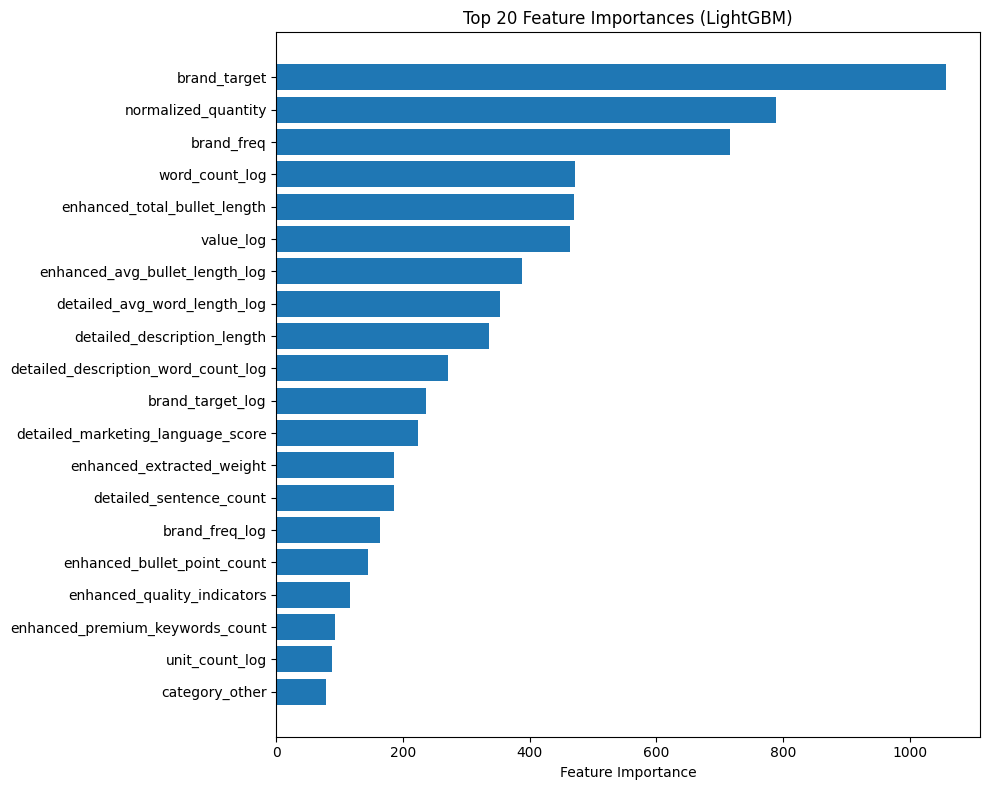

In [47]:
def run_baseline_model(X_train, X_val, y_train, y_val):
    """Run LightGBM baseline model for feature importance"""
    
    # Convert to LightGBM dataset
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    # LightGBM parameters
    params = {
        'objective': 'regression',
        'metric': 'mape',
        'learning_rate': 0.1,
        'num_leaves': 31,
        'max_depth': -1,
        'min_data_in_leaf': 20,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbosity': -1,
        'random_state': 42
    }
    
    # Train model
    print("Training LightGBM baseline model...")
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=True),
            lgb.log_evaluation(period=100)
        ]
    )
    
    # Feature importance
    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importance()
    }).sort_values('importance', ascending=False)
    
    print("\n=== TOP 20 FEATURE IMPORTANCES ===")
    for i, row in importance_df.head(20).iterrows():
        print(f"{row['feature']}: {row['importance']}")
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(20)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Feature Importances (LightGBM)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return model, importance_df

lgb_model, importance_df = run_baseline_model(X_train_scaled, X_val_scaled, y_train, y_val)

### Mutual information analysis

=== TOP 20 MUTUAL INFORMATION SCORES ===
brand_target: 0.7710
brand_target_log: 0.7632
value_log: 0.2774
brand_freq: 0.2640
normalized_quantity: 0.2627
brand_freq_log: 0.2615
detailed_description_length: 0.1919
detailed_sentence_count: 0.1886
detailed_description_word_count_log: 0.1729
detailed_avg_word_length_log: 0.1415
detailed_confidence_indicators: 0.1180
word_count_log: 0.1089
enhanced_extracted_weight_log: 0.1006
enhanced_avg_bullet_length_log: 0.0998
enhanced_extracted_weight: 0.0954
enhanced_total_bullet_length: 0.0916
detailed_has_warranty_info: 0.0457
enhanced_premium_keywords_count: 0.0444
enhanced_bullet_point_count: 0.0402
enhanced_quality_indicators: 0.0401


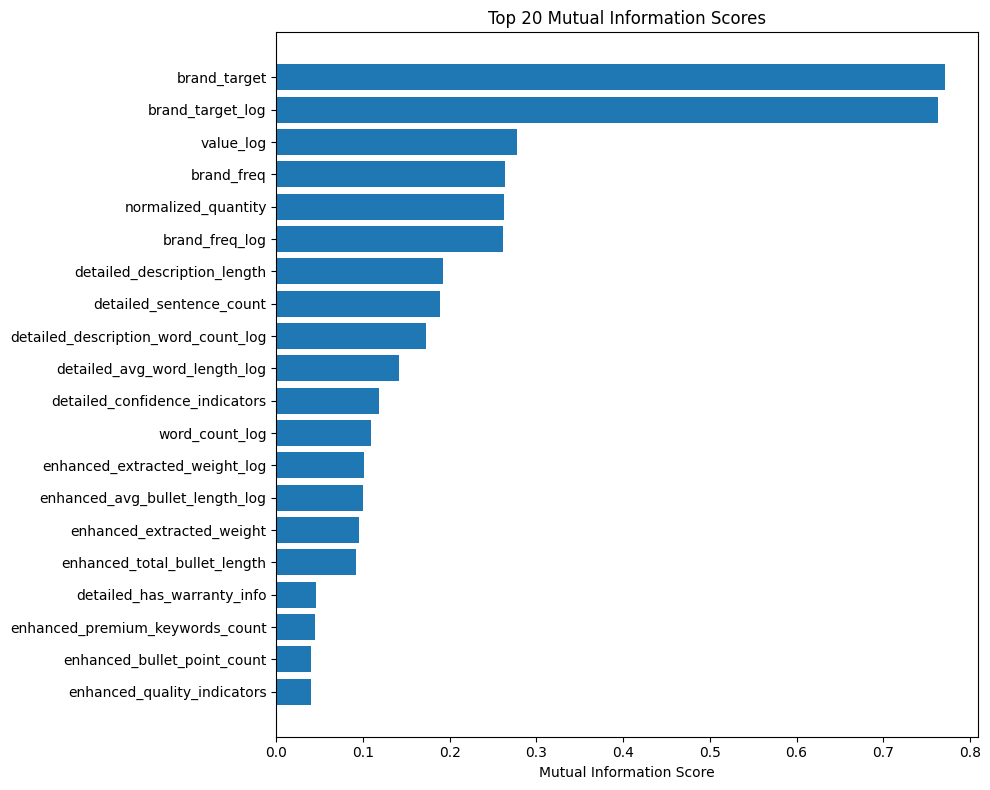

In [48]:
def mutual_information_analysis(X_train, y_train):
    """Calculate mutual information between features and target"""
    mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_train.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    
    print("=== TOP 20 MUTUAL INFORMATION SCORES ===")
    for feature, score in mi_scores.head(20).items():
        print(f"{feature}: {score:.4f}")
    
    # Plot MI scores
    plt.figure(figsize=(10, 8))
    top_mi = mi_scores.head(20)
    plt.barh(top_mi.index, top_mi.values)
    plt.xlabel('Mutual Information Score')
    plt.title('Top 20 Mutual Information Scores')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return mi_scores

mi_scores = mutual_information_analysis(X_train_scaled, y_train)

### Remove low importance features

In [49]:
def remove_low_importance_features(X_train, X_val, X_test, importance_df, mi_scores, 
                                 importance_threshold=10, mi_threshold=0.001):
    """Remove features with low importance and low mutual information"""
    
    # Features to keep based on importance
    important_features = importance_df[importance_df['importance'] >= importance_threshold]['feature'].tolist()
    
    # Features to keep based on mutual information
    informative_features = mi_scores[mi_scores >= mi_threshold].index.tolist()
    
    # Intersection of both criteria
    features_to_keep = list(set(important_features) & set(informative_features))
    
    # Always keep sample_id if present and important features
    if 'sample_id' in X_train.columns:
        features_to_keep.append('sample_id')
    
    print(f"Keeping {len(features_to_keep)} features after filtering")
    print(f"Removed {X_train.shape[1] - len(features_to_keep)} low importance features")
    
    # Filter datasets
    X_train_filtered = X_train[features_to_keep]
    X_val_filtered = X_val[features_to_keep]
    X_test_filtered = X_test[features_to_keep]
    
    return X_train_filtered, X_val_filtered, X_test_filtered, features_to_keep

X_train_final, X_val_final, X_test_final, final_features = remove_low_importance_features(
    X_train_scaled, X_val_scaled, X_test_scaled, importance_df, mi_scores
)


Keeping 35 features after filtering
Removed 62 low importance features


### Save clean datasets

In [50]:
def save_clean_datasets(X_train, X_val, X_test, y_train, y_val, y_test, 
                       train_df, val_df, test_df, final_features):
    """Save the cleaned and processed datasets"""
    
    # Save features and labels separately
    features_clean = pd.concat([X_train, X_val, X_test], axis=0)
    labels_clean = pd.concat([y_train, y_val, y_test], axis=0)
    
    # Add sample_id back if available
    if 'sample_id' in train_df.columns:
        sample_ids = pd.concat([train_df['sample_id'], val_df['sample_id'], test_df['sample_id']], axis=0)
        features_clean['sample_id'] = sample_ids.values
        labels_df = pd.DataFrame({'sample_id': sample_ids.values, 'price': labels_clean.values})
    else:
        labels_df = pd.DataFrame({'price': labels_clean.values})
    
    # Save to CSV
    features_clean.to_csv('features_clean.csv', index=False)
    labels_df.to_csv('labels.csv', index=False)
    
    # Save feature names
    feature_names = [f for f in final_features if f != 'sample_id']
    with open('feature_names.txt', 'w') as f:
        for feature in feature_names:
            f.write(f"{feature}\n")
    
    print("=== CLEAN DATASETS SAVED ===")
    print(f"features_clean.csv: {features_clean.shape}")
    print(f"labels.csv: {labels_df.shape}")
    print(f"Feature names saved to: feature_names.txt")
    print(f"Final number of features: {len(feature_names)}")
    
    return features_clean, labels_df

features_clean, labels_df = save_clean_datasets(
    X_train_final, X_val_final, X_test_final, y_train, y_val, y_test,
    train_df, val_df, test_df, final_features
)


=== CLEAN DATASETS SAVED ===
features_clean.csv: (75000, 36)
labels.csv: (75000, 2)
Feature names saved to: feature_names.txt
Final number of features: 35


###  Final summary

In [51]:
def print_final_summary(original_shape, final_shape, removed_features, skewed_features):
    """Print final preprocessing summary"""
    print("\n" + "="*50)
    print("PREPROCESSING COMPLETED SUCCESSFULLY!")
    print("="*50)
    
    print(f"\nOriginal data shape: {original_shape}")
    print(f"Final data shape: {final_shape}")
    print(f"Features reduced from {original_shape[1]-2} to {final_shape[1]-1} (excluding target)")
    
    print(f"\nTransformations applied:")
    print(f"  - Handled missing values in 'value' column")
    print(f"  - Encoded categorical features (brand, category, unit)")
    print(f"  - Applied log transformation to {len(skewed_features)} skewed features")
    print(f"  - Removed {len(removed_features)} redundant features")
    print(f"  - Scaled numerical features using StandardScaler")
    print(f"  - Split data into train/validation/test (70%/15%/15%)")
    
    print(f"\nFiles created:")
    print(f"  - features_clean.csv: Clean features for modeling")
    print(f"  - labels.csv: Target prices")
    print(f"  - feature_names.txt: List of final feature names")

print_final_summary(
    features_df.shape, 
    features_clean.shape, 
    removed_features, 
    skewed_features
)

print("\nData is now ready for modeling! 🚀")


PREPROCESSING COMPLETED SUCCESSFULLY!

Original data shape: (75000, 32)
Final data shape: (75000, 36)
Features reduced from 30 to 35 (excluding target)

Transformations applied:
  - Handled missing values in 'value' column
  - Encoded categorical features (brand, category, unit)
  - Applied log transformation to 85 skewed features
  - Removed 85 redundant features
  - Scaled numerical features using StandardScaler
  - Split data into train/validation/test (70%/15%/15%)

Files created:
  - features_clean.csv: Clean features for modeling
  - labels.csv: Target prices
  - feature_names.txt: List of final feature names

Data is now ready for modeling! 🚀
